In [55]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/home-credit-default-risk/sample_submission.csv
/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv
/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/competitions/home-credit-default-risk/application_train.csv
/kaggle/input/competitions/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/competitions/home-credit-default-risk/application_test.csv
/kaggle/input/competitions/home-credit-default-risk/previous_application.csv
/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv
/kaggle/input/competitions/home-credit-default-risk/bureau.csv


In [56]:
#import useful libraries

import sys 
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)


import tarfile
import urllib

# Get the data

In [57]:
application_train_df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')
application_test_df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_test.csv')

bureau_df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/bureau.csv')
bureau_balance_df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv')
POS_CASH_balance_df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv')
credit_card_balance_df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv')
previous_application_df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/previous_application.csv')
installments_payments_df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv')
HomeCredit_columns_description_df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/HomeCredit_columns_description.csv', encoding='latin1')



# Data Understanding 

In [58]:
# lets start the training data

num_cols = application_train_df.select_dtypes(include=['number'])
cat_cols = application_train_df.select_dtypes(include=['object', 'category'])

print("Numerical columns in the data set:", num_cols.shape[1])
print("Categorical columns in the data set:", cat_cols.shape[1])
print("Number of columns in the data set", (num_cols + cat_cols).shape[1])

Numerical columns in the data set: 106
Categorical columns in the data set: 16
Number of columns in the data set 122


In [59]:
# target variable
print(application_train_df["TARGET"].value_counts())

TARGET
0    282686
1     24825
Name: count, dtype: int64


In [60]:
print("Numerical cols info:", application_train_df.select_dtypes(include = ['number']).columns)
print("---------------------------------------------------------------------------------------")
print("Categorical cols info", application_train_df.select_dtypes(include = ['object', 'category']).columns) 

Numerical cols info: Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=106)
---------------------------------------------------------------------------------------
Categorical cols info Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE

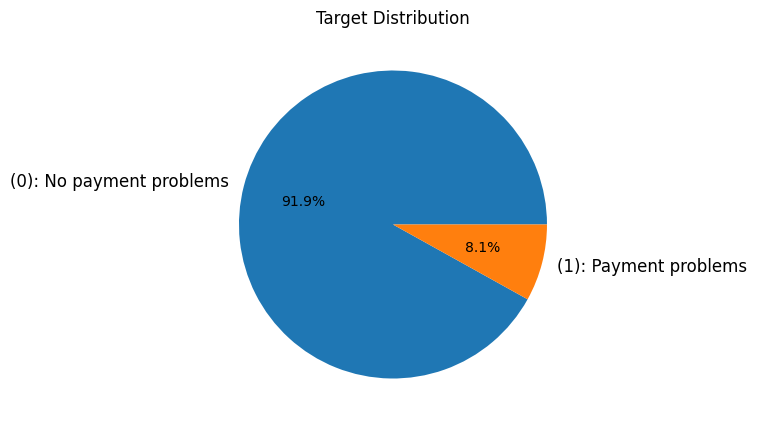

--------------------------------------------------------------------------------
Finantial information per target (raw)


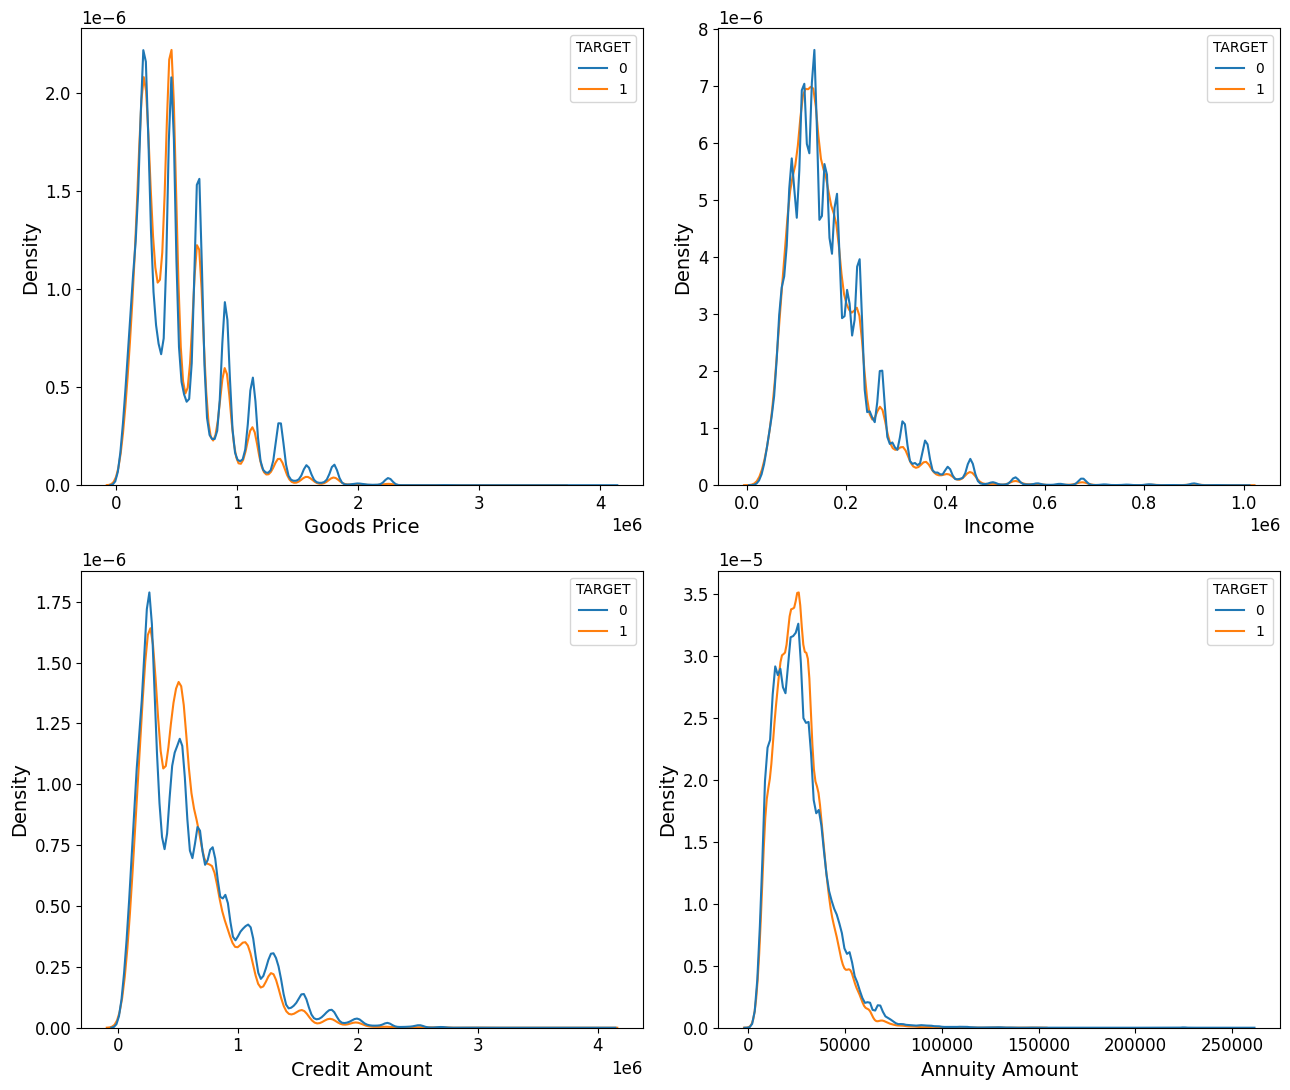

--------------------------------------------------------------------------------
Personal information per target (raw)


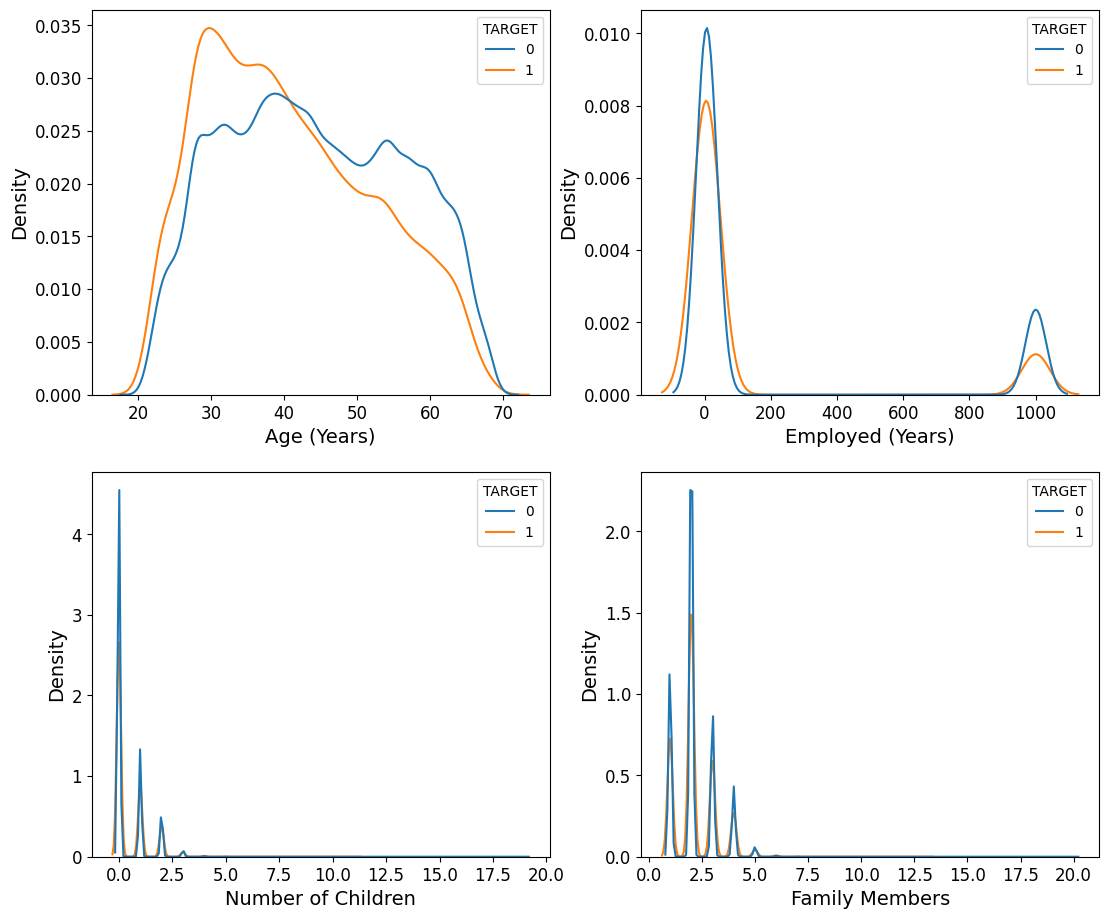

--------------------------------------------------------------------------------
External risk scores


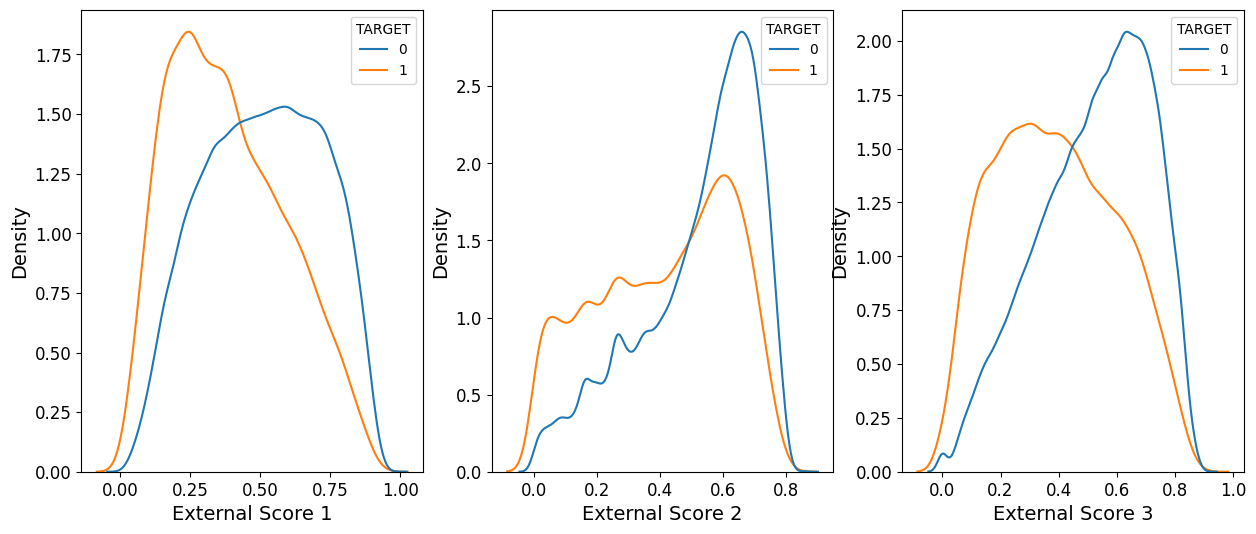

--------------------------------------------------------------------------------
Credit Bareau


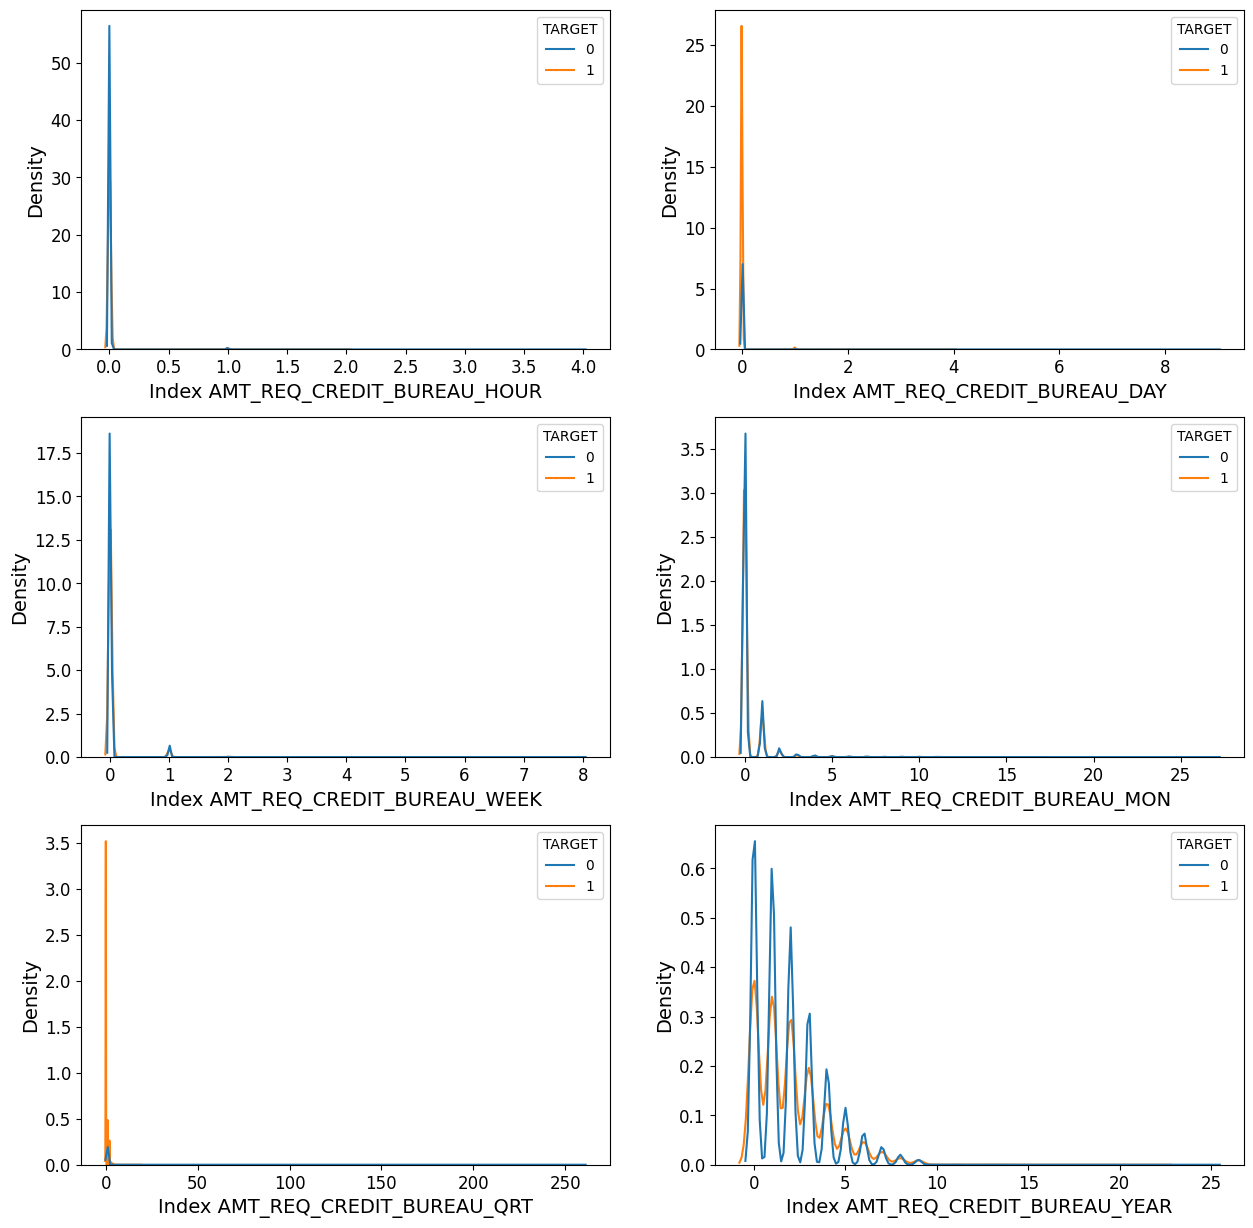

In [61]:
# lets make some visualizations
import seaborn as sns
import math 

# distribution for the target variable (data imbalance)
fig, axs = plt.subplots(figsize=(7,5))
axs.pie(application_train_df["TARGET"].value_counts(), 
        labels = ["(0): No payment problems", "(1): Payment problems"],
       autopct = "%1.1f%%")
axs.set_title("Target Distribution")
plt.show()
plt.close()

print("--------------------------------------------------------------------------------")
print("Finantial information per target (raw)")
# lets see the total income distribution for each target 
fig, axs = plt.subplots(2,2,figsize=(13,11))
axs = axs.flatten()

sns.kdeplot(data=application_train_df,
           x = "AMT_GOODS_PRICE",
           hue="TARGET",
           common_norm=False,
           ax=axs[0]
)
axs[0].set_xlabel("Goods Price")

# Income
sns.kdeplot(
    data=application_train_df[
        application_train_df["AMT_INCOME_TOTAL"] < 1_000_000
    ],
    x="AMT_INCOME_TOTAL",
    hue="TARGET",
    common_norm=False,
    ax=axs[1]
)
axs[1].set_xlabel("Income")

# Credit
sns.kdeplot(
    data=application_train_df,
    x="AMT_CREDIT",
    hue="TARGET",
    common_norm=False,
    ax=axs[2]
)
axs[2].set_xlabel("Credit Amount")

# Annuity
sns.kdeplot(
    data=application_train_df,
    x="AMT_ANNUITY",
    hue="TARGET",
    common_norm=False,
    ax=axs[3]
)
axs[3].set_xlabel("Annuity Amount")

plt.tight_layout()
plt.show()
plt.close()

print("--------------------------------------------------------------------------------")
print("Personal information per target (raw)")

fig, axs = plt.subplots(2,2,figsize=(13,11))
axs = axs.flatten()

# age distributions 
# lets to convert in years
application_train_df["AGE_YEARS"] = np.abs(application_train_df["DAYS_BIRTH"])/365
application_test_df["AGE_YEARS"] = np.abs(application_test_df["DAYS_BIRTH"])/365

sns.kdeplot(
        data=application_train_df,
        x="AGE_YEARS",
        hue="TARGET",
        common_norm=False,
        ax=axs[0]
)
axs[0].set_xlabel("Age (Years)")

# employment information
application_train_df["EMPLOYED_YEARS"] = np.abs(application_train_df["DAYS_EMPLOYED"])/365
application_test_df["EMPLOYED_YEARS"] = np.abs(application_test_df["DAYS_EMPLOYED"])/365

sns.kdeplot(
        data=application_train_df,
        x="EMPLOYED_YEARS",
        hue="TARGET",
        common_norm=False,
        ax=axs[1]
)
axs[1].set_xlabel("Employed (Years)")

sns.kdeplot(
        data=application_train_df,
        x="CNT_CHILDREN",
        hue="TARGET",
        common_norm=False,
        ax=axs[2]
)
axs[2].set_xlabel("Number of Children")

sns.kdeplot(
        data=application_train_df,
        x="CNT_FAM_MEMBERS",
        hue="TARGET",
        common_norm=False,
        ax=axs[3]
)
axs[3].set_xlabel("Family Members")

plt.show()
plt.close()

print("--------------------------------------------------------------------------------")
print("External risk scores")

fig, axs = plt.subplots(1,3,figsize=(15,6))
axs = axs.flatten()

sns.kdeplot(
    data=application_train_df,
    x = "EXT_SOURCE_1",
    hue = "TARGET",
    common_norm = False,
    ax=axs[0]
)
axs[0].set_xlabel("External Score 1")

sns.kdeplot(
    data=application_train_df,
    x = "EXT_SOURCE_2",
    hue = "TARGET",
    common_norm = False,
    ax=axs[1]
)
axs[1].set_xlabel("External Score 2")

sns.kdeplot(
    data=application_train_df,
    x = "EXT_SOURCE_3",
    hue = "TARGET",
    common_norm = False,
    ax=axs[2]
)

axs[2].set_xlabel("External Score 3")

plt.show()
plt.close()

print("--------------------------------------------------------------------------------")
print("Credit Bareau")

bareau_variables = ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 
               'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
               'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']

fig, axs = plt.subplots(3,2,figsize=(15,15))
axes = axs.flatten()

for i, (var, a) in enumerate(zip(bareau_variables, axes)):
    sns.kdeplot(
        data = application_train_df, 
        x = var,
        hue = "TARGET",
        common_norm = False,
        ax=a
    )
    a.set_xlabel(f"Index {var}")

plt.show()
plt.close()

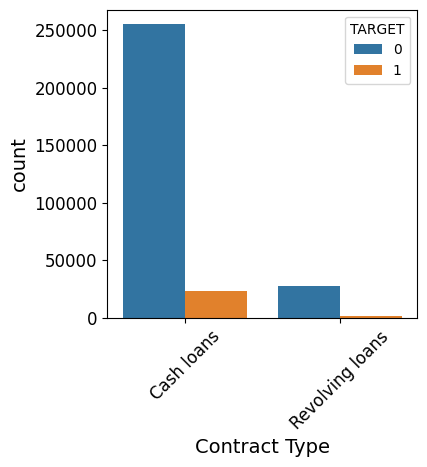

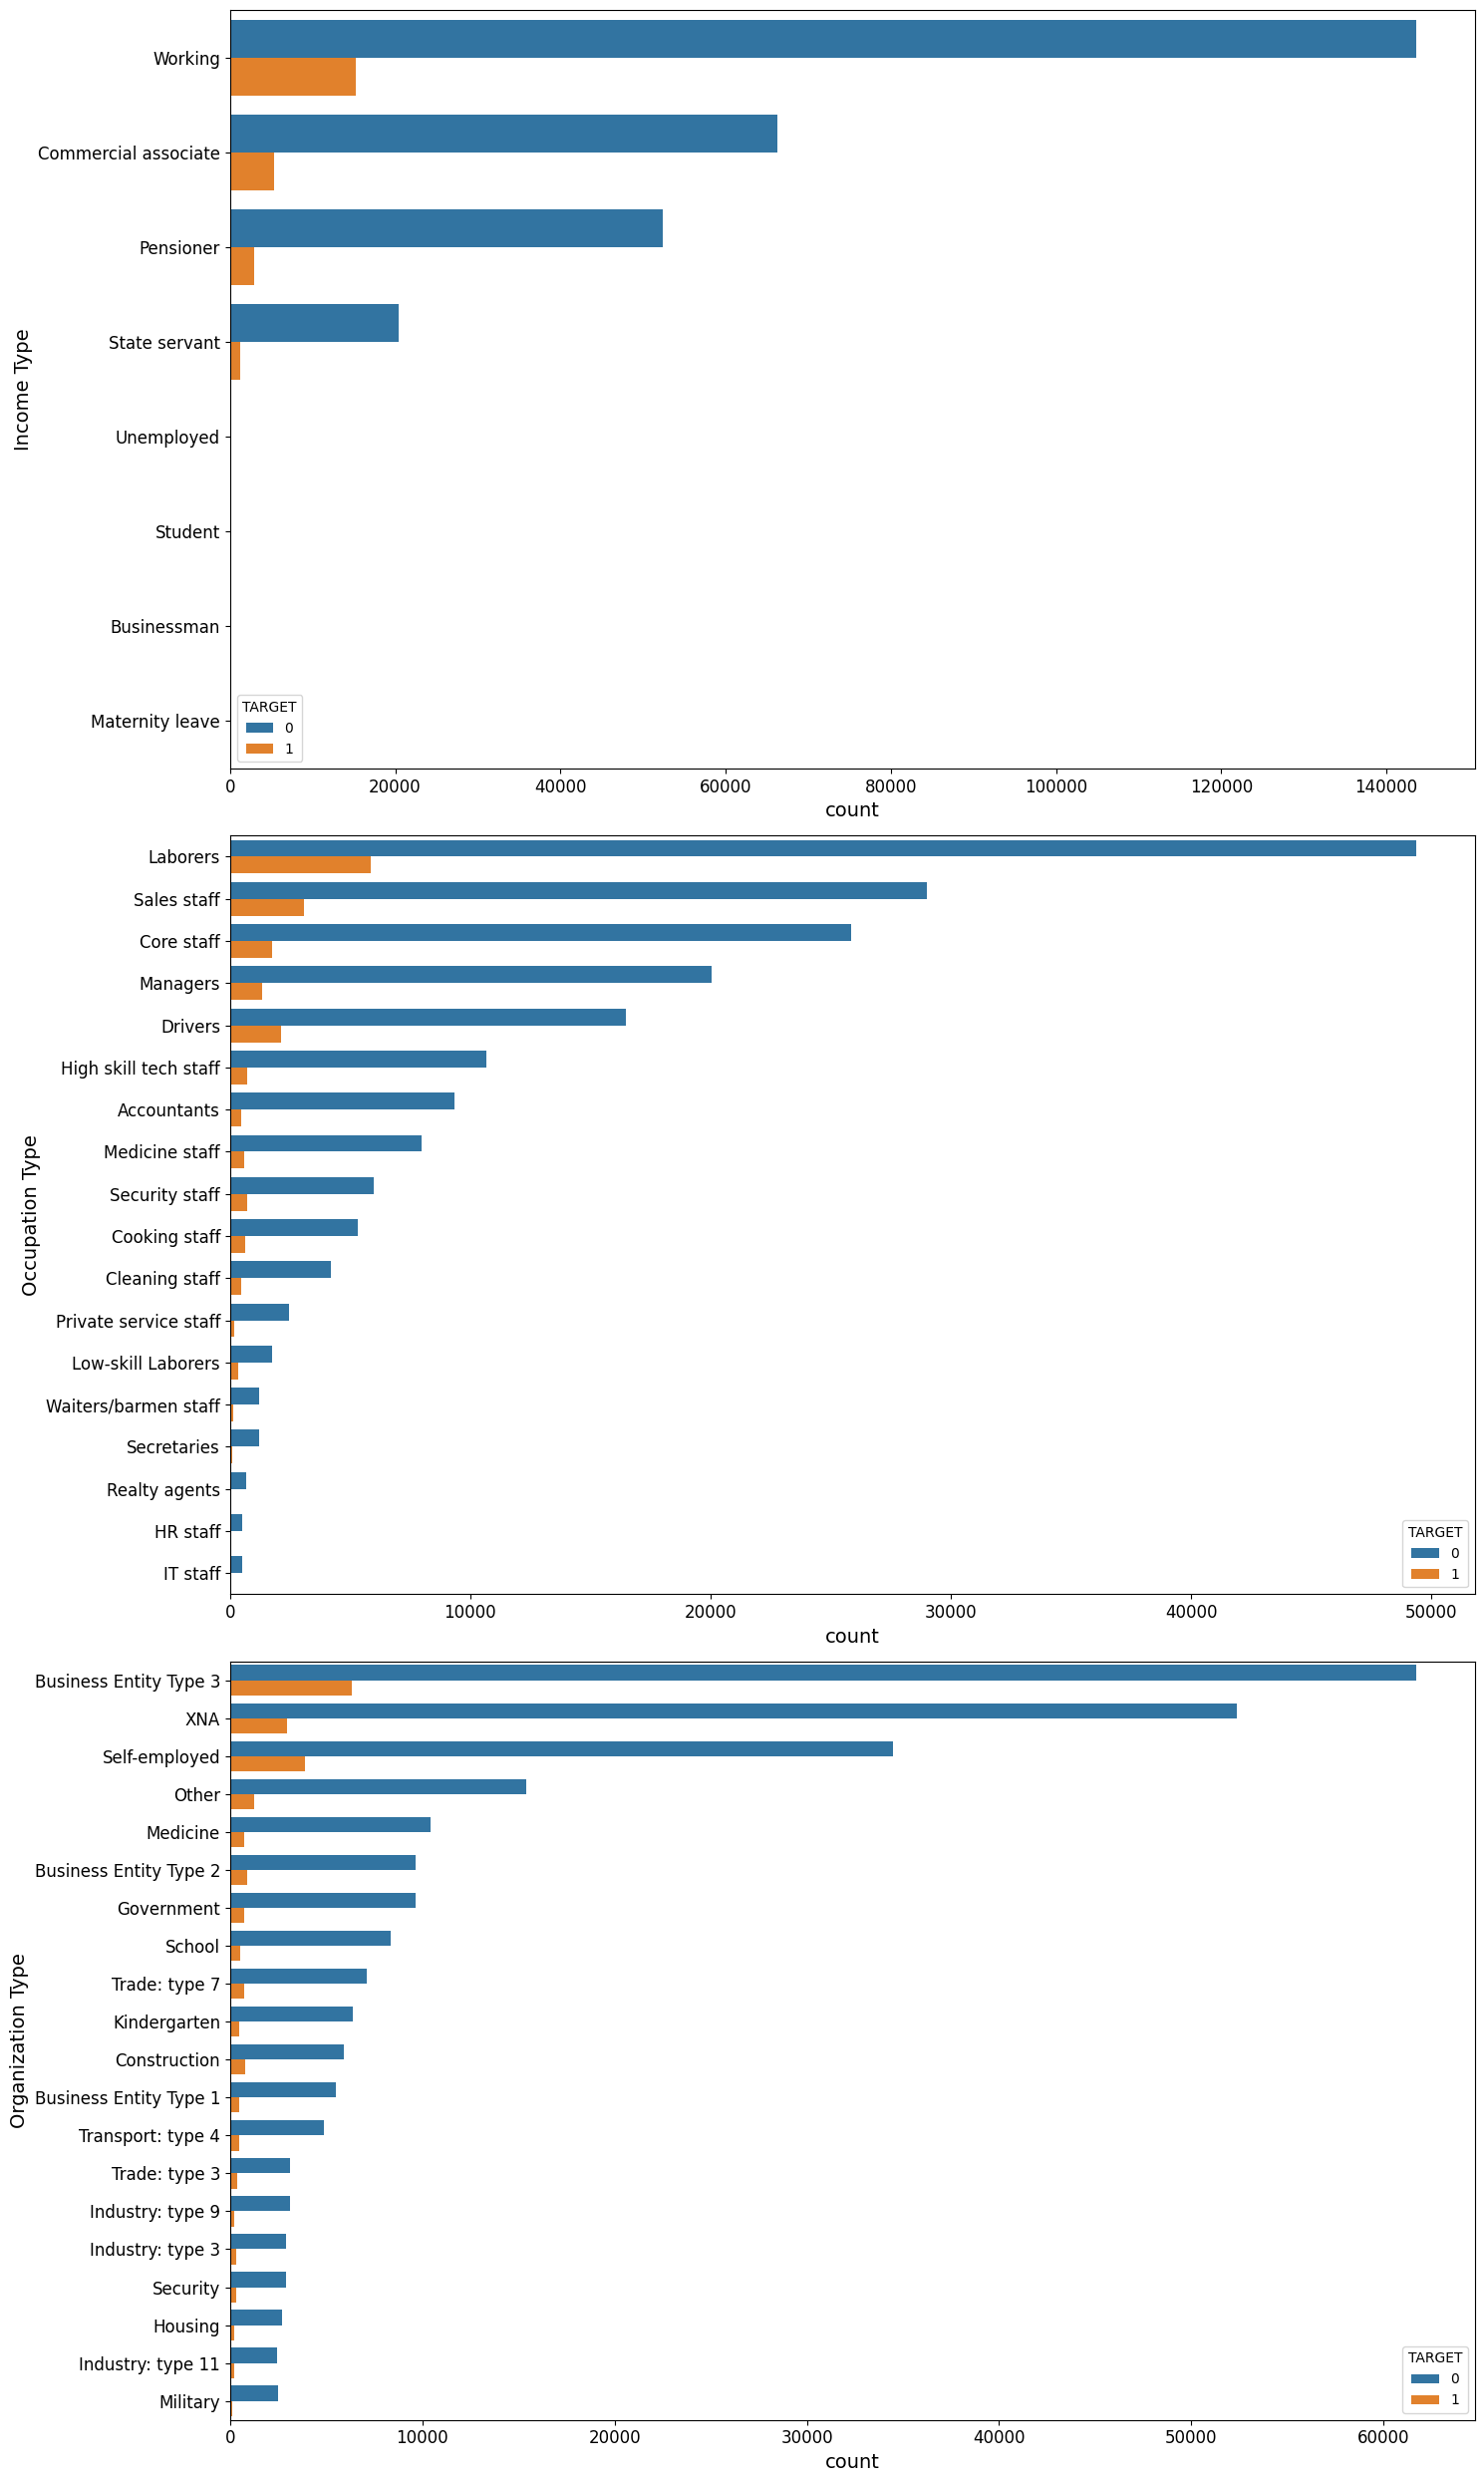

In [62]:
# lets plot some categorical variables

plt.figure(figsize=(4,4))
#contract type
sns.countplot(
    data=application_train_df,
    x="NAME_CONTRACT_TYPE",
    hue = 'TARGET'
)
plt.xticks(rotation=45)
plt.xlabel("Contract Type")
plt.show()
plt.close()

fig, axs = plt.subplots(3,1, figsize=(15,25))
axs = axs.flatten()
income_order = (
    application_train_df["NAME_INCOME_TYPE"].value_counts().index
)
#income type
sns.countplot(
    data=application_train_df,
    y="NAME_INCOME_TYPE",
    order=income_order,
    hue = 'TARGET',
    ax=axs[0]
)
axs[0].set_ylabel("Income Type")
# occupation type
occupation_order = (application_train_df["OCCUPATION_TYPE"].value_counts().index)
sns.countplot(
    data=application_train_df,
    y="OCCUPATION_TYPE",
    order=occupation_order,
    hue = 'TARGET',
    ax=axs[1]
)
axs[1].set_ylabel("Occupation Type")
# organization type
org_order = (
    application_train_df["ORGANIZATION_TYPE"].value_counts().head(20).index
)

sns.countplot(
    data=application_train_df[application_train_df["ORGANIZATION_TYPE"].isin(org_order)],
    y="ORGANIZATION_TYPE",
    order=org_order,
    hue = 'TARGET',
    ax=axs[2]
)

axs[2].set_ylabel("Organization Type")
plt.tight_layout()
plt.show()
plt.close()








In [63]:
# lets handle with outliers

application_train_df["CNT_CHILDREN"] = (application_train_df["CNT_CHILDREN"].replace(19, np.nan))
application_train_df["DAYS_EMPLOYED"] = (application_train_df["DAYS_EMPLOYED"].replace(365243, np.nan))
application_train_df.loc[application_train_df["EMPLOYED_YEARS"] > 100, "EMPLOYED_YEARS"] = np.nan


In [64]:
application_train_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,EMPLOYED_YEARS
count,307511.000000,307511.000000,307509.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,252137.000000,...,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,307511.000000,252137.000000
mean,278180.518577,0.080729,0.416931,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,-2384.169325,...,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974,43.936973,6.531971
std,102790.175348,0.272419,0.720567,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,2338.360162,...,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295,11.956133,6.406466
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.517808,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-3175.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34.008219,2.101370
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1648.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,43.150685,4.515068
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-767.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,53.923288,8.698630
max,456255.000000,1.000000,14.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,0.000000,...,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000,69.120548,49.073973


In [65]:
# lets overview the correlation with the target variable
corr_matrix = (application_train_df.select_dtypes(include="number").
               corr()["TARGET"].sort_values(key = np.abs, ascending = False))


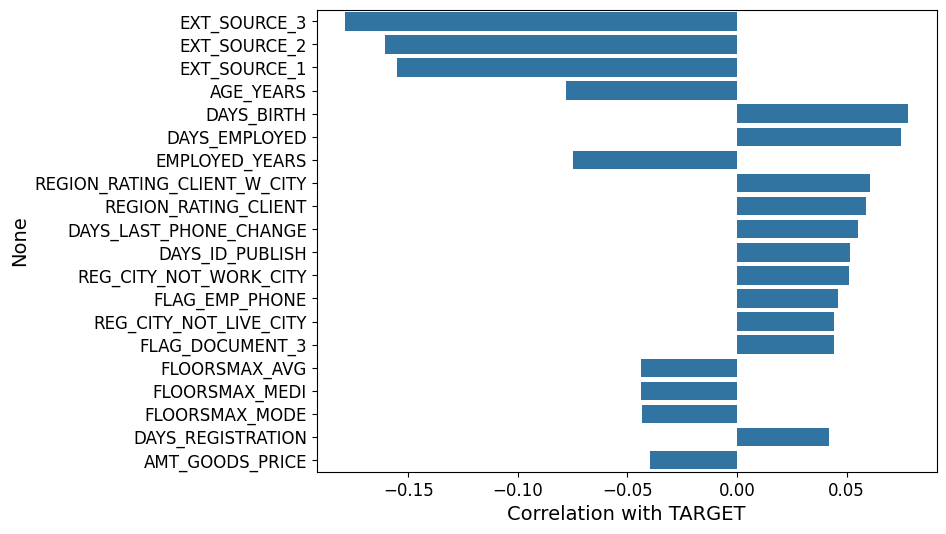

In [66]:
top_corr = corr_matrix.drop("TARGET").head(20)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.xlabel("Correlation with TARGET")
plt.show()

# Feature engine

In [67]:
# finance variables 

def feature_on_current_data(application_df):
    df = application_df.copy()
    df["DEBT_BURDEN"] = df["AMT_CREDIT"]/df["AMT_INCOME_TOTAL"]
    df["PAYMENT_BURDEN"] = df["AMT_ANNUITY"]/df["AMT_INCOME_TOTAL"]
    df["CREDIT_GOODS_RATIO"]    = df["AMT_CREDIT"]  / df["AMT_GOODS_PRICE"].replace(0, np.nan)
    df["CREDIT_TO_AGE_RATIO"]   = df["AMT_CREDIT"]  / df["AGE_YEARS"].replace(0, np.nan)
    
    df["EXT_SOURCE_MEAN"] = (df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1))
    df["EXT_SOURCE_MIN"]  = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].min(axis=1)
    df["EXT_SOURCE_STD"]  = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].std(axis=1)
    df["EXT_SOURCE_PROD"] = (df["EXT_SOURCE_1"] * df["EXT_SOURCE_2"] * df["EXT_SOURCE_3"])
    df["EXT_SOURCE_x_AGE"]      = df["EXT_SOURCE_MEAN"] * df["AGE_YEARS"]
    df["EXT_SOURCE_x_EMPLOYED"] = df["EXT_SOURCE_MEAN"] * df["EMPLOYED_YEARS"]

    df["EMPLOYED_TO_AGE_RATIO"] = df["EMPLOYED_YEARS"] / df["AGE_YEARS"].replace(0, np.nan)
    
    return df



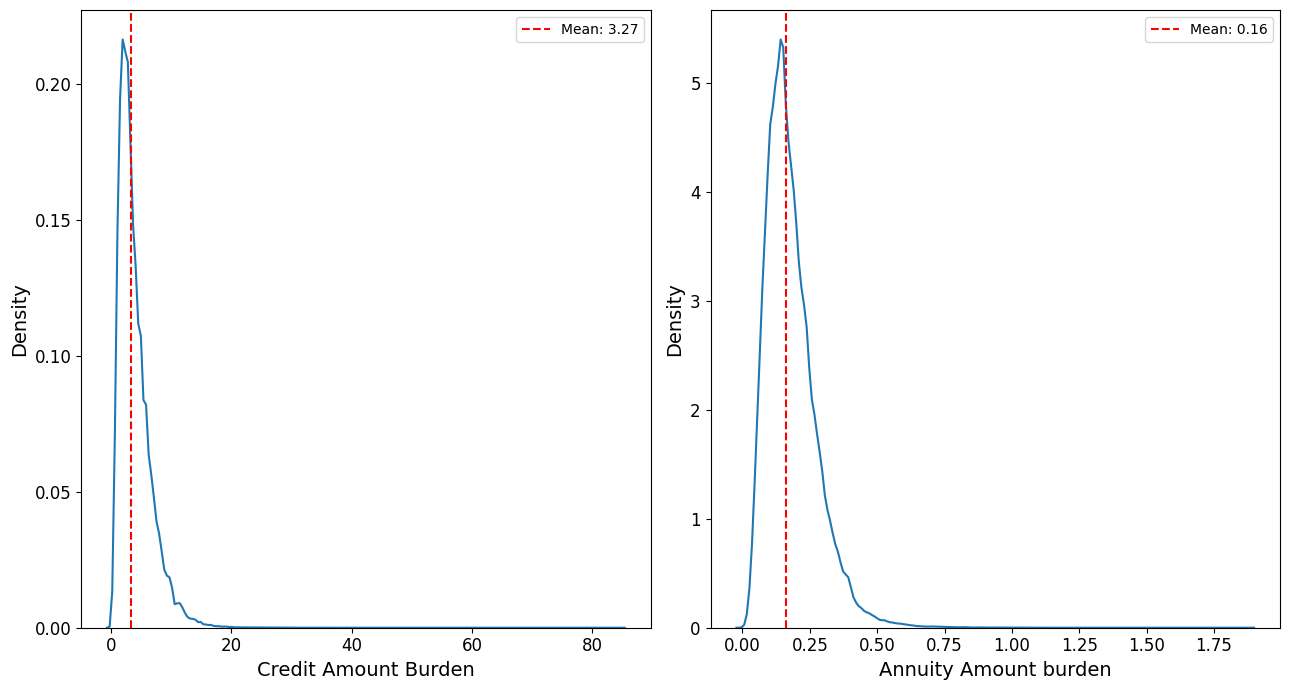

Customers typically request credit amounts equivalent to 3.27 times their annual income.
Customers typically must assume periodic payments equivalent to 16.28% of their annual income.


In [68]:
# lets see the total income distribution for each target 
fig, axs = plt.subplots(1,2,figsize=(13,7))
axs = axs.flatten()

# Credit
sns.kdeplot(
    data = feature_on_current_data(application_train_df),
    x="DEBT_BURDEN",
    common_norm=False,
    ax=axs[0]
)
axs[0].set_xlabel("Credit Amount Burden")
axs[0].axvline(x = feature_on_current_data(application_train_df)["DEBT_BURDEN"].median(), color = 'red', linestyle = '--',
               label = f"Mean: {feature_on_current_data(application_train_df)["DEBT_BURDEN"].median():.2f}" )
axs[0].legend()

# Annuity
sns.kdeplot(
    data=feature_on_current_data(application_train_df),
    x="PAYMENT_BURDEN",
    common_norm=False,
    ax=axs[1]
)
axs[1].set_xlabel("Annuity Amount burden")
axs[1].axvline(x = feature_on_current_data(application_train_df)["PAYMENT_BURDEN"].median(), color = 'red', linestyle = '--',
               label = f"Mean: {feature_on_current_data(application_train_df)["PAYMENT_BURDEN"].median():.2f}" )
axs[1].legend()

plt.tight_layout()
plt.show()
plt.close()

print(
    f"Customers typically request credit amounts equivalent to "
    f"{feature_on_current_data(application_train_df)['DEBT_BURDEN'].median():.2f} "
    f"times their annual income."
)

print(
   f"Customers typically must assume periodic payments equivalent to "
   f"{feature_on_current_data(application_train_df)['PAYMENT_BURDEN'].median():.2%} "
   f"of their annual income."
)


## Join Table Information


### External credit history

In [69]:
bureau_balance_df.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [70]:
bureau_df.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [71]:
###################### bureau ####################################################
def feature_on_bureau(bureau_df, bureau_balance_df):
    # this tell us the active credit 
    active_bureau = bureau_df[bureau_df["CREDIT_ACTIVE"] == "Active"]
    # this tell us the debt to credit ratio per customer for active 
    debt_to_credit_ratio_bureau  = (
        active_bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM_DEBT"].sum() /
        active_bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM"].sum().replace(0, np.nan)
    )
    # this tell us the maximum days the customer delay
    max_overdue_bureau = bureau_df.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"].max()
    ### bureau_balance ##############
    # Modify the status column 
    bureau_balance_df["STATUS_MOD"] = (
        pd.to_numeric(bureau_balance_df["STATUS"], errors = "coerce")
        .fillna(0)
        .astype(int)
    )
    # get for each SK_ID_CURR the worst status
    worst_status_curr = (
        bureau_balance_df.groupby("SK_ID_BUREAU")["STATUS_MOD"]
        .max()
        .reset_index()
        .merge(bureau_df[["SK_ID_BUREAU", "SK_ID_CURR"]], on="SK_ID_BUREAU")
        .groupby("SK_ID_CURR")["STATUS_MOD"]
        .max()
        .rename("WORST_STATUS")   
    )
    ### Merge bureau info into train_data ##
    debt_to_credit = debt_to_credit_ratio_bureau.rename("DEBT_TO_CREDIT_RATIO").reset_index()
    max_overdue    = max_overdue_bureau.rename("MAX_OVERDUE_DAYS").reset_index()
    worst_status   = worst_status_curr.rename("WORST_STATUS").reset_index()
    # merge everything
    bureau_features = (
        debt_to_credit
        .merge(max_overdue,  on="SK_ID_CURR", how="outer")
        .merge(worst_status, on="SK_ID_CURR", how="outer")
    )
    return bureau_features


### Previous application for HOME Credit

In [72]:
previous_application_df.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
POS_CASH_balance_df.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [74]:
credit_card_balance_df.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [75]:
installments_payments_df.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [76]:
############# previous application ####################

def feature_on_prev_home_credit(previous_df, pos_df, cc_df, inst_df):
    ## get the previous approval rate
    previous_df["IS_APPROVED"] = (
        previous_df["NAME_CONTRACT_STATUS"] == "Approved").astype(int)

    previous_info = previous_df.groupby("SK_ID_CURR").agg(
        PREV_COUNT   = ("SK_ID_PREV", "count"),
        PREV_APPROVED_COUNT = ("IS_APPROVED",  "sum"),
    )

    previous_info["PREV_APPROVAL_RATE"] = (
        previous_info["PREV_APPROVED_COUNT"] / previous_info["PREV_COUNT"]
    )

    #### POS_CASH_balance ###########

    pos_df["IS_BAD_MONTH"] = (pos_df["SK_DPD"] > 0).astype(int)

    pos_features = pos_df.groupby("SK_ID_CURR").agg(
        POS_MONTHS_COUNT     = ("MONTHS_BALANCE", "count"),
        POS_MAX_DPD          = ("SK_DPD", "max"),
        POS_BAD_MONTHS_COUNT = ("IS_BAD_MONTH",    "sum"),
    ).reset_index()

    #### Credit_card_balance ###########

    # define the utility

    cc_df["UTILITY"] = (
        cc_df["AMT_BALANCE"] /
        cc_df["AMT_CREDIT_LIMIT_ACTUAL"].replace(0,np.nan)
    )

    cc_features = cc_df.groupby("SK_ID_CURR").agg(
        CC_UTILITY_MEAN = ("UTILITY", "mean"), 
        CC_UTILITY_MAX  = ("UTILITY", "max"),
    ).reset_index()

    ####### Installment_balance ###########

    inst_df["DAYS_LATE"] = (
        inst_df["DAYS_ENTRY_PAYMENT"] -
        inst_df["DAYS_INSTALMENT"]
    )
    inst_df["PAYMENT_RATIO"] = (
        inst_df["AMT_PAYMENT"] /
        inst_df["AMT_INSTALMENT"].replace(0,np.nan)
    )
    inst_features = inst_df.groupby("SK_ID_CURR").agg(
        INST_MAX_DAYS_LATE   = ("DAYS_LATE", "max"),     
        INST_MEAN_DAYS_LATE  = ("DAYS_LATE", "mean"),     
        INST_PAYMENT_RATIO   = ("PAYMENT_RATIO", "mean"), 
    ).reset_index()

    # merge everything
    prev_all = (
        previous_info
        .merge(pos_features,  on="SK_ID_CURR", how="left")
        .merge(cc_features,   on="SK_ID_CURR", how="left")
        .merge(inst_features, on="SK_ID_CURR", how="left")
    )
    return prev_all

In [77]:
##  apply feature engine
feature_on_bureau = feature_on_bureau(bureau_df, bureau_balance_df)
feature_on_prev_home_credit = feature_on_prev_home_credit(previous_application_df, POS_CASH_balance_df, 
                            credit_card_balance_df, 
                            installments_payments_df)


In [78]:
# apply feature engine into train and test data

train_df = feature_on_current_data(application_train_df)
train_df = train_df.merge(feature_on_bureau,   on="SK_ID_CURR", how="left")
train_df = train_df.merge(feature_on_prev_home_credit, on="SK_ID_CURR", how="left")

# Test 
test_df = feature_on_current_data(application_test_df)
test_df = test_df.merge(feature_on_bureau,   on="SK_ID_CURR", how="left")
test_df = test_df.merge(feature_on_prev_home_credit, on="SK_ID_CURR", how="left")

# Data Cleaning

In [79]:
print("missing data")
missing_df = pd.DataFrame(
    {"Missing Values": train_df.isnull().sum(),
    "Percentage": 100 * train_df.isnull().mean()
    })

missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df = missing_df.sort_values("Missing Values", ascending=False)

print(missing_df)


missing data
                        Missing Values  Percentage
CC_UTILITY_MAX                  222179   72.250749
CC_UTILITY_MEAN                 222179   72.250749
WORST_STATUS                    215280   70.007252
COMMONAREA_MODE                 214865   69.872297
COMMONAREA_AVG                  214865   69.872297
...                                ...         ...
AMT_ANNUITY                         12    0.003902
PAYMENT_BURDEN                      12    0.003902
CNT_FAM_MEMBERS                      2    0.000650
CNT_CHILDREN                         2    0.000650
DAYS_LAST_PHONE_CHANGE               1    0.000325

[93 rows x 2 columns]


In [80]:
# now the duplicate values
print("duplicate")
train_df.duplicated().sum()


duplicate


np.int64(0)

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# features and target
X = train_df.drop(columns=["TARGET"]).replace([np.inf, -np.inf], np.nan)
y = train_df["TARGET"]

#split train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y 
)
# First select only numeric columns, then check for inf
numeric_train = X_train.select_dtypes(include=[np.number])
assert not np.isinf(numeric_train).any().any(), "Still has inf values in X_train!"

# Column types
train_num_attribs = X_train.select_dtypes(include=["number"]).columns.tolist()
train_cat_attribs = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# build pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, train_num_attribs),
    ("cat", cat_pipeline, train_cat_attribs),
])

# Fit on train and trasform 
train_prepared = full_pipeline.fit_transform(X_train)  # learns from train only
val_prepared   = full_pipeline.transform(X_val)         # only applies learned stats

X_test = test_df.replace([np.inf, -np.inf], np.nan)
test_prepared = full_pipeline.transform(X_test)


# Train a Model

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier

# RandomForest

rdf_cl = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42)

rdf_cl.fit(train_prepared, y_train)

# XGBoost

xgb_cl =  XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), # handles imbalance
    random_state=42,
    eval_metric="auc",
    n_jobs=-1
)

xgb_cl.fit(train_prepared, y_train,
    eval_set=[(val_prepared, y_val)],  # monitors AUC on val during training
    verbose=100)



[0]	validation_0-auc:0.72654
[100]	validation_0-auc:0.76697
[200]	validation_0-auc:0.77073
[299]	validation_0-auc:0.77105


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

ROC-AUC RandomForest: 0.7554
ROC-AUC XGBoost: 0.7710


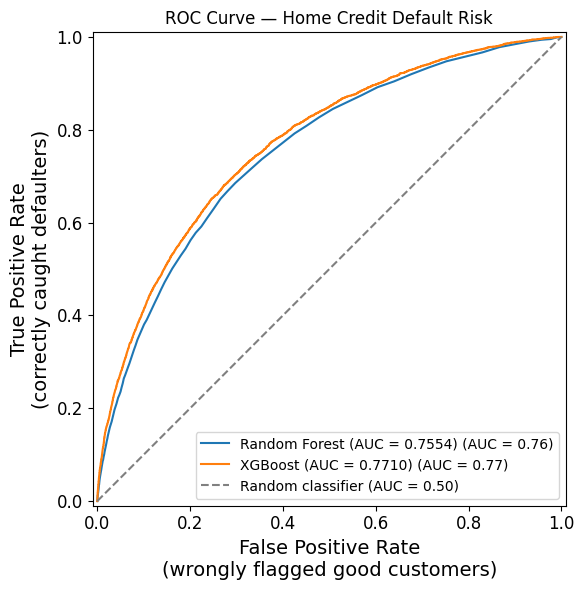

In [83]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay

# predict on test data

y_pred = rdf_cl.predict(val_prepared)

y_pred_prob_rdf = rdf_cl.predict_proba(val_prepared)[:,1]

auc_rdf = roc_auc_score(y_val, y_pred_prob_rdf)

print(f"ROC-AUC RandomForest: {auc_rdf:.4f}")

y_pred_prob_xgb = xgb_cl.predict_proba(val_prepared)[:, 1]
auc_xgb = roc_auc_score(y_val, y_pred_prob_xgb)
print(f"ROC-AUC XGBoost: {auc_xgb:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    rdf_cl,
    val_prepared,
    y_val,
    ax=ax,
    name=f"Random Forest (AUC = {auc_rdf:.4f})"
)

RocCurveDisplay.from_estimator(
    xgb_cl,
    val_prepared,
    y_val,
    ax=ax,
    name=f"XGBoost (AUC = {auc_xgb:.4f})"
)

# Reference line — random classifier
ax.plot([0, 1], [0, 1], 
        linestyle="--", 
        color="gray", 
        label="Random classifier (AUC = 0.50)")

ax.set_title("ROC Curve — Home Credit Default Risk")
ax.set_xlabel("False Positive Rate\n(wrongly flagged good customers)")
ax.set_ylabel("True Positive Rate\n(correctly caught defaulters)")
ax.legend()
plt.tight_layout()
plt.show()
plt.close()



# Evaluating predictions

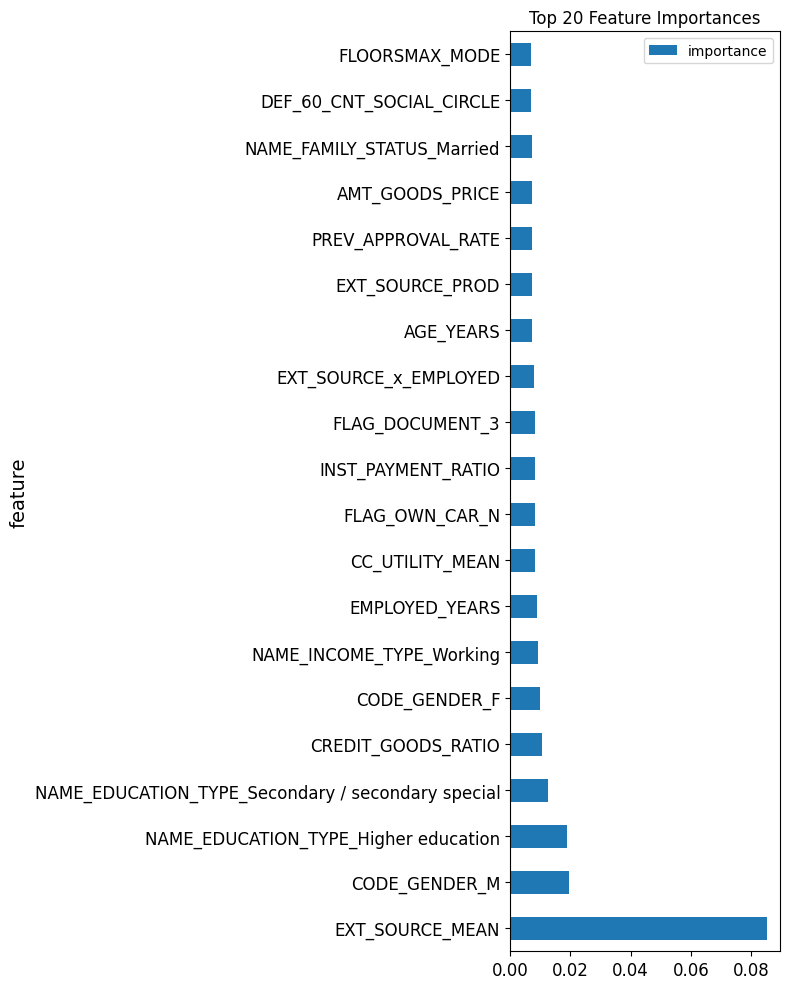

Top 20 features:
 1. EXT_SOURCE_MEAN
 2. CODE_GENDER_M
 3. NAME_EDUCATION_TYPE_Higher education
 4. NAME_EDUCATION_TYPE_Secondary / secondary special
 5. CREDIT_GOODS_RATIO
 6. CODE_GENDER_F
 7. NAME_INCOME_TYPE_Working
 8. EMPLOYED_YEARS
 9. CC_UTILITY_MEAN
10. FLAG_OWN_CAR_N
11. INST_PAYMENT_RATIO
12. FLAG_DOCUMENT_3
13. EXT_SOURCE_x_EMPLOYED
14. AGE_YEARS
15. EXT_SOURCE_PROD
16. PREV_APPROVAL_RATE
17. AMT_GOODS_PRICE
18. NAME_FAMILY_STATUS_Married
19. DEF_60_CNT_SOCIAL_CIRCLE
20. FLOORSMAX_MODE


In [84]:
feature_names = (train_num_attribs + 
                 list(full_pipeline
                      .named_transformers_["cat"]
                      .named_steps["encoder"]
                      .get_feature_names_out(train_cat_attribs))
                )

importance_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": xgb_cl.feature_importances_
}).sort_values("importance", ascending=False).head(20)


importance_df.plot(kind="barh", x="feature", y="importance", figsize=(8, 10))
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()


print("Top 20 features:")
for i, feature in enumerate(importance_df["feature"].tolist(), start=1):
    print(f"{i:2}. {feature}")